# Day 03 — Mel scale and log-Mel features

**Learn block summary (defensible without derivations):**

- **Human perception is not linear in frequency.** We hear 200 vs 300 Hz clearly but 5000 vs 5100 Hz barely at all. The **Mel scale** maps frequency to perceived pitch: `mel(f) = 2595·log10(1 + f/700)`. Equal steps in Mel = equal perceived steps.
- **The filterbank.** `n_mels` overlapping triangular filters sit on the linear-frequency axis, spaced evenly *in Mel* (narrow at low Hz, wide at high Hz). Each frame's STFT bins are weighted and summed into per-frame Mel energies.
- **Log compression.** Mel energies span ~10 orders of magnitude; `10·log10` compresses the range like human loudness perception and makes quiet structure visible.
- **Bins and dynamic range.** More bins = finer detail but more compute and redundancy; **80 is the modern ASR standard** (Conformer / FastConformer front-end). The log floor (−100 dB relative to peak) fixes the dynamic range.
- **Normalization.** Raw log-Mel offsets are utterance-dependent; per-utterance mean/std standardization is recorded in the metadata for reproducibility.

**Pipeline trace (completion check):**

`waveform → power STFT (25 ms / 10 ms) → Mel filterbank (80 bands) → log + floor → log-Mel tensor + metadata`

In [1]:
from pathlib import Path
import sys

REPO = Path("..").resolve()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import matplotlib.pyplot as plt
import torch

from src.audio.loader import load_audio
from src.audio.features import (
    DEFAULT_FLOOR_DB,
    DEFAULT_HOP_16K,
    DEFAULT_N_MELS,
    DEFAULT_N_FFT_16K,
    compute_log_mel,
    mel_filterbank_matrix,
)

wave1, sr = load_audio(REPO / "data/clean_16k/clean_01.wav", target_sr=16000)
print(f"clean_01: {wave1.numel() / sr:.2f}s @ {sr} Hz, tensor {tuple(wave1.shape)}")

clean_01: 6.00s @ 16000 Hz, tensor (1, 96000)


metadata: LogMelMetadata(sample_rate=16000, n_fft=400, hop_length=160, n_mels=80, f_min=0.0, f_max=8000.0, log_floor_db=-100.0, num_frames=601, duration_s=6.0, mean=None, std=None)
log-Mel tensor: (80, 601)  (80 bands x 601 frames)


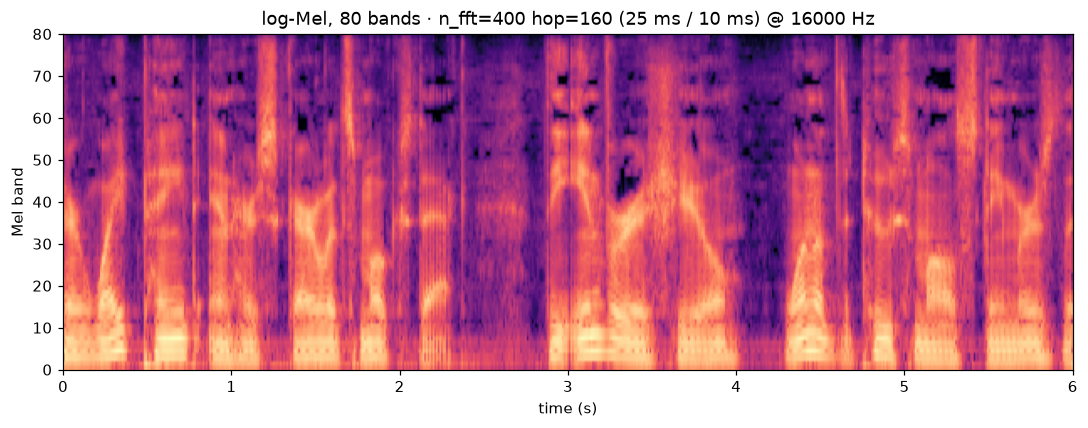

In [2]:
# Baseline: 80-band log-Mel with the project defaults (25 ms window / 10 ms hop).
log_mel, meta = compute_log_mel(wave1, sr)
print("metadata:", meta)
print(f"log-Mel tensor: {tuple(log_mel.shape)}  ({meta.n_mels} bands x {meta.num_frames} frames)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(log_mel.numpy(), origin="lower", aspect="auto",
          extent=(0, meta.duration_s, 0, meta.n_mels), cmap="magma",
          vmin=meta.log_floor_db, vmax=0)
ax.set_xlabel("time (s)")
ax.set_ylabel("Mel band")
ax.set_title(f"log-Mel, {meta.n_mels} bands · n_fft={meta.n_fft} hop={meta.hop_length} "
             f"({meta.n_fft / sr * 1000:.0f} ms / {meta.hop_length / sr * 1000:.0f} ms) @ {meta.sample_rate} Hz")
fig.tight_layout()

## The filterbank itself

The matrix is (201 linear bins × 80 Mel bands). Each column is one triangular
filter: it multiplies a small group of adjacent STFT bins and sums them into a
single Mel energy. Triangles are spaced evenly in **Mel**, so in Hz they are
narrow at the bottom and wide at the top.

triangular width in linear bins: band 0 = 1 | band 39 = 4 | band 79 = 13


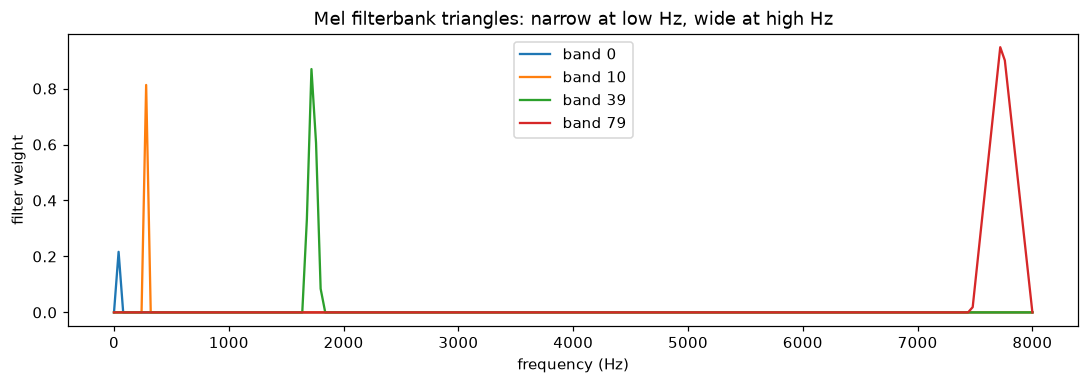

In [3]:
fb = mel_filterbank_matrix(sample_rate=sr, n_fft=DEFAULT_N_FFT_16K, n_mels=DEFAULT_N_MELS)
bin_hz = sr / DEFAULT_N_FFT_16K
freqs = torch.arange(fb.shape[0]) * bin_hz

widths = (fb > 0).sum(dim=0)
print("triangular width in linear bins: band 0 =", int(widths[0]),
      "| band 39 =", int(widths[39]), "| band 79 =", int(widths[79]))

fig, ax = plt.subplots(figsize=(10, 3.6))
for band in (0, 10, 39, 79):
    ax.plot(freqs.numpy(), fb[:, band].numpy(), label=f"band {band}")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("filter weight")
ax.set_title("Mel filterbank triangles: narrow at low Hz, wide at high Hz")
ax.legend()
fig.tight_layout()

## Experiment A — Mel bin count varies, audio held constant

Three feature extractors (40 / 80 / 128 bands) running on the *same* 6 s
utterance. Watch what happens to the visual structure (formant bands) and to
compute size (tensor elements / KB). Also watch for a **filterbank coverage
warning at 128 bands with n_fft=400** — if some top triangles have no linear
bins to cover, that itself is a measured finding (128 bands need a larger
FFT, or they silently waste rows).

note (n_mels=128): At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
n_mels  frames  elements  size (KB)
    40     601     24040       93.9
    80     601     48080      187.8
   128     601     76928      300.5


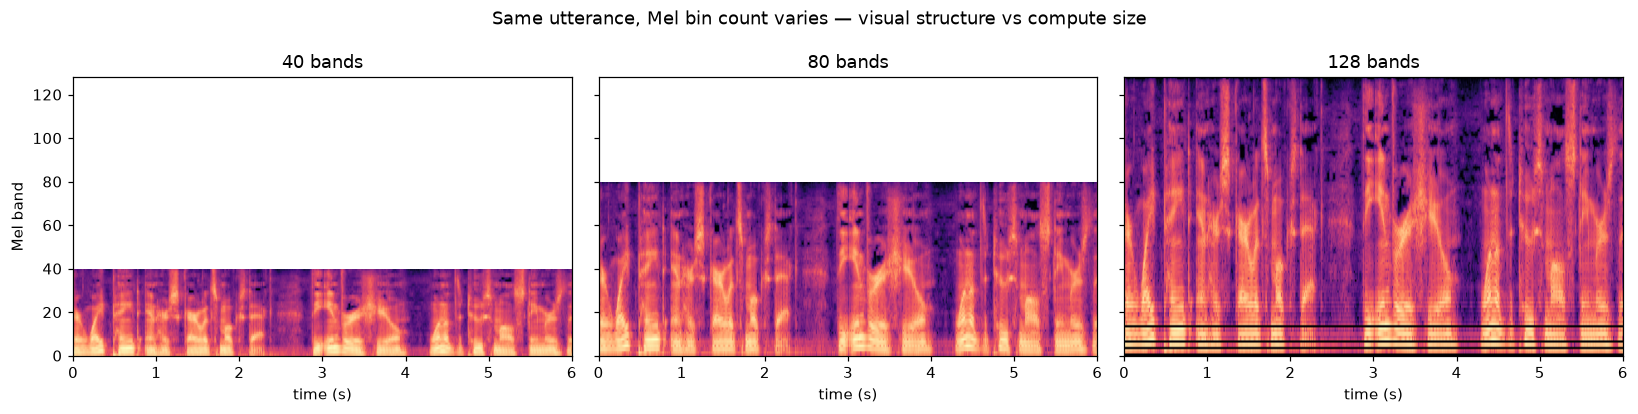

In [4]:
import warnings

n_mels_options = (40, 80, 128)
rows = []
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
for ax, n_mels in zip(axes, n_mels_options):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        lm, m = compute_log_mel(wave1, sr, n_mels=n_mels)
    for warning in caught:
        print(f"note (n_mels={n_mels}): {warning.message}")
    elements = lm.numel()
    rows.append((n_mels, elements, elements * 4 / 1024, m.num_frames))
    ax.imshow(lm.numpy(), origin="lower", aspect="auto",
              extent=(0, m.duration_s, 0, m.n_mels), cmap="magma",
              vmin=m.log_floor_db, vmax=0)
    ax.set_title(f"{n_mels} bands")
    ax.set_xlabel("time (s)")
axes[0].set_ylabel("Mel band")
fig.suptitle("Same utterance, Mel bin count varies — visual structure vs compute size")
fig.tight_layout()
fig.savefig(REPO / "results/day03_mel_bins_comparison.png", dpi=150)

print(f"{'n_mels':>6} {'frames':>7} {'elements':>9} {'size (KB)':>10}")
for n_mels, elements, kb, frames in rows:
    print(f"{n_mels:>6} {frames:>7} {elements:>9} {kb:>10.1f}")

## Experiment B — shape consistency across utterance lengths

The batching contract: `n_mels` is a fixed property of the extractor, while
the frame count scales with duration. Compare two clips of different length
(clean_01 = 6.00 s, clean_03 = 6.50 s).

      clip  dur (s)  n_mels   frames          shape
  clean_01     6.00      80      601      (80, 601)
  clean_03     6.50      80      651      (80, 651)


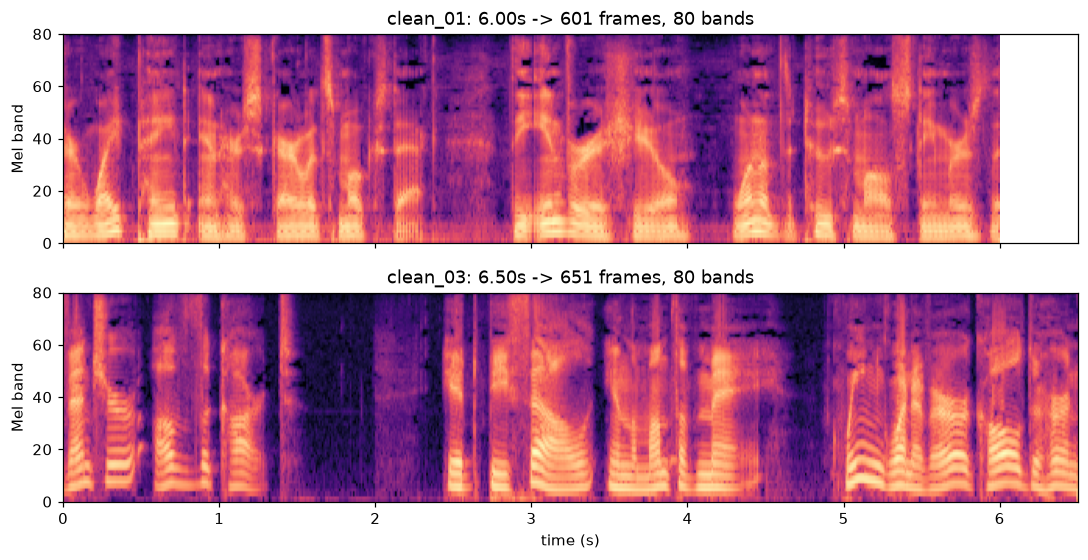

In [5]:
wave3, sr3 = load_audio(REPO / "data/clean_16k/clean_03.wav", target_sr=16000)
assert sr3 == sr
lm1, m1 = compute_log_mel(wave1, sr)
lm3, m3 = compute_log_mel(wave3, sr)

print(f"{'clip':>10} {'dur (s)':>8} {'n_mels':>7} {'frames':>8} {'shape':>14}")
for name, lm, m in (("clean_01", lm1, m1), ("clean_03", lm3, m3)):
    print(f"{name:>10} {m.duration_s:>8.2f} {m.n_mels:>7} {m.num_frames:>8} {str(tuple(lm.shape)):>14}")

fig, axes = plt.subplots(2, 1, figsize=(10, 5.2), sharex=True)
for ax, (lm, m, name) in zip(axes, ((lm1, m1, "clean_01"), (lm3, m3, "clean_03"))):
    ax.imshow(lm.numpy(), origin="lower", aspect="auto",
              extent=(0, m.duration_s, 0, m.n_mels), cmap="magma",
              vmin=m.log_floor_db, vmax=0)
    ax.set_ylabel("Mel band")
    ax.set_title(f"{name}: {m.duration_s:.2f}s -> {m.num_frames} frames, {m.n_mels} bands")
axes[-1].set_xlabel("time (s)")
fig.tight_layout()

## Completion check — the full trace with real numbers

| Step | Operation | Result |
| :--- | :--- | :--- |
| 1 | `load_audio` (Day 1) | waveform `[96000]`, 6.00 s @ 16 kHz |
| 2 | power STFT, n_fft=400 hop=160 (Day 2) | `[201 × 601]` linear bins × frames |
| 3 | Mel filterbank, 80 triangular bands | `[80 × 601]` Mel energies |
| 4 | `10·log10` + peak→0 dB + floor −100 dB | `[80 × 601]` log-Mel |
| 5 | metadata record | every parameter (sr, n_fft, hop, n_mels, f_min, f_max, floor, frames, duration) |

80 bands with a 25 ms / 10 ms window at 16 kHz — exactly the front-end the
ASR encoder (Weeks 2–5) will consume. Determined by statistics, not
defaults: bandwidth explodes from 1 to 13 linear bins across the Mel axis,
70 % of the old 201-bin spectrum was perceptual redundancy.